# Using refl1d to analyse a simple dataset

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from refl1d.names import *
import bumps
from bumps.fitters import fit

In [2]:
# load 4 column data into a Q-probe.
probe = load4("c_PLP0011859_q.txt")

# the dq column is expressed in that dataset as a FWHM, so divide by 2.35.
probe.dQ /= 2.3548

In [3]:
# creating some SLD objects to describe the layers
Si = SLD(name="Si", rho=2.0737, irho=2.376e-5)
SiO2 = SLD(name="SiO2", rho=3.4)
D2O = SLD(name="D2O", rho=6.36)
polymer = SLD(name="polymer", rho=2.5)

# we'll use a common roughness for all the interfaces, apart from Si/SiO2
rough = Parameter(4, name="roughness")

# the roughness for layer N is between N/N+1
sample = Si(0, 3) | SiO2(15, rough) | polymer(250, rough) | D2O(0, 0)

In [4]:
# The sample stack was described in the order fronting-->backing, so change backing_reflectivity
probe.back_reflectivity = True

# change parameter bounds
probe.background.range(1e-7, 2e-6)
probe.background.value = 1e-6
probe.intensity.range(0.8, 1.2)

sample[1].thickness.range(5, 50)
SiO2.rho.range(3.31, 3.474)
sample[2].thickness.range(200, 300)
polymer.rho.range(1, 4)
rough.range(1, 10);

In [5]:
M = Experiment(probe=probe, sample=sample)

In [6]:
problem = FitProblem(M)

In [11]:
_ = fit(problem, method='lm')

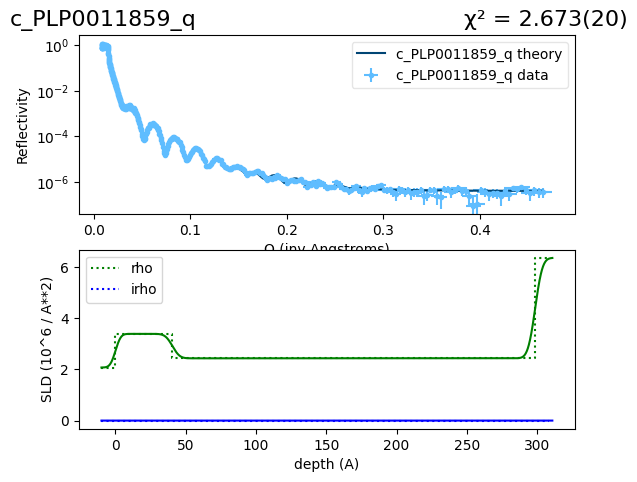

In [12]:
problem.plot()

In [13]:
for p in problem.parameters:
    print(f"{str(p):<30s}: {p.value:10}")

background c_PLP0011859_q     : 4.114433743805108e-07
intensity c_PLP0011859_q      : 0.8815211405043505
roughness                     : 4.078395407440865
SiO2 rho                      : 3.3883845200336893
SiO2 thickness                : 40.515496289538596
polymer rho                   : 2.4334654628698296
polymer thickness             : 258.0832170883024


In [18]:
problem.parameters[0].pm()

TypeError: Parameter.pm() missing 1 required positional argument: 'plus'